# **Exploratory Data Analysis**
Extracting insights using visual and statistical exploration
Dataset: TITANIC DATASET(from kaggle.com)

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


____________________________________________________________________________________________________________________
### **Using :**
.describe(), .info(), .value_counts()

In [79]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [80]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [81]:
print(df['Survived'].value_counts())
print(df['Sex'].value_counts())
print(df['Pclass'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64
Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


____________________________________________________________________________________________________________________
### **Cleaning The Data :**

In [82]:
print("\n BEFORE (empty values):")
print(df.isnull().sum())
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'], errors='ignore')
df = df.dropna(subset=['Embarked'])
print("AFTER:")
print(df.isnull().sum())


 BEFORE (empty values):
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
AFTER:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


____________________________________________________________________________________________________________________
### **Identifying relationships and trends**
#### Plotting histograms, boxplots, scatterplots :

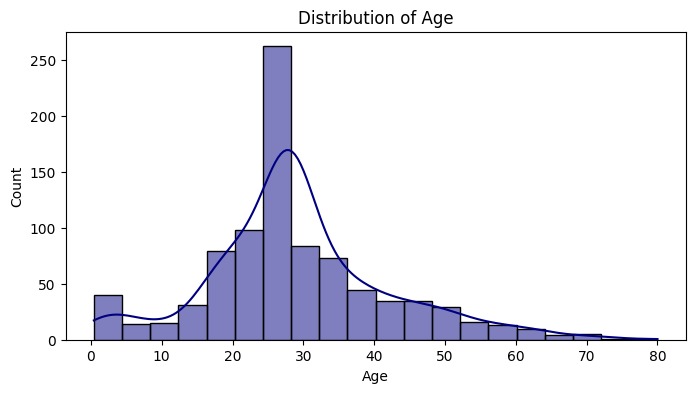

<Figure size 640x480 with 0 Axes>

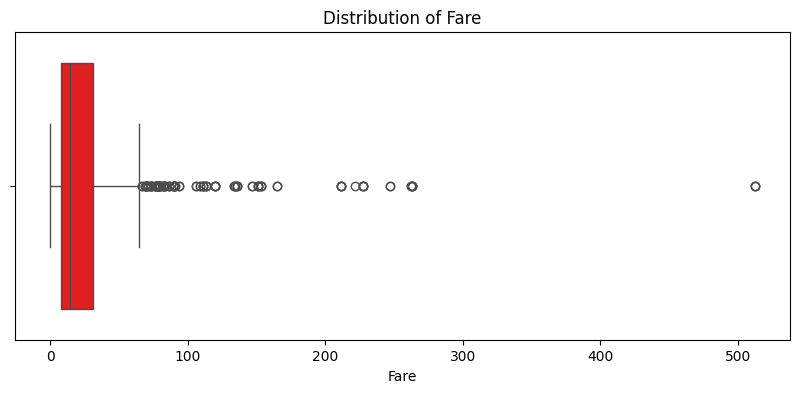

<Figure size 640x480 with 0 Axes>

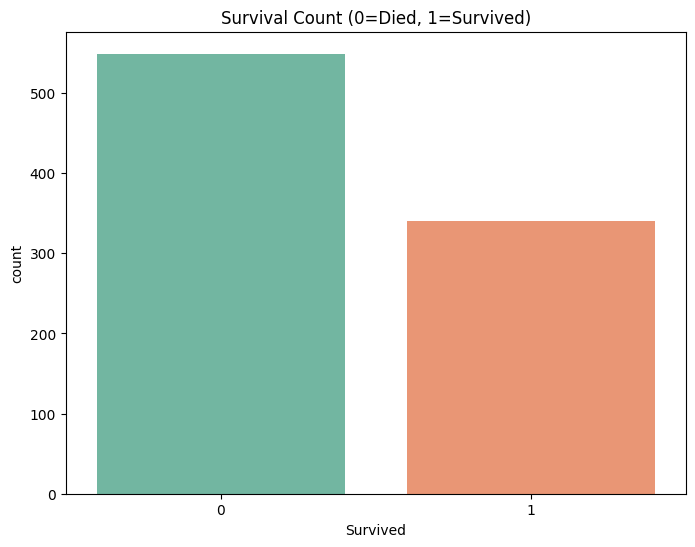

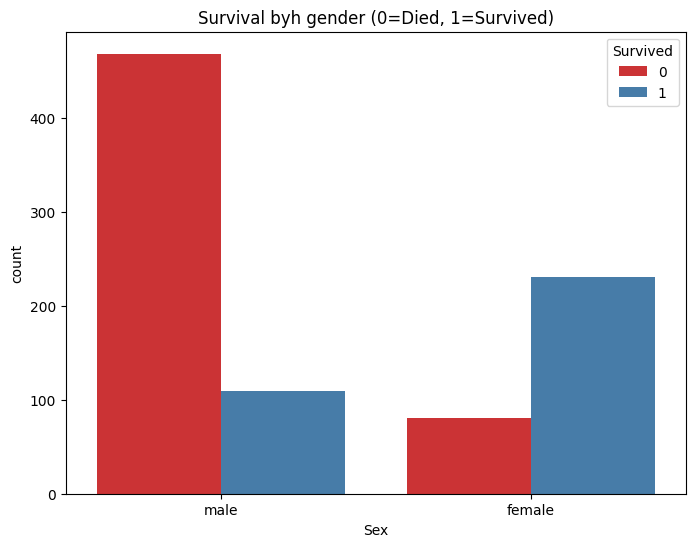

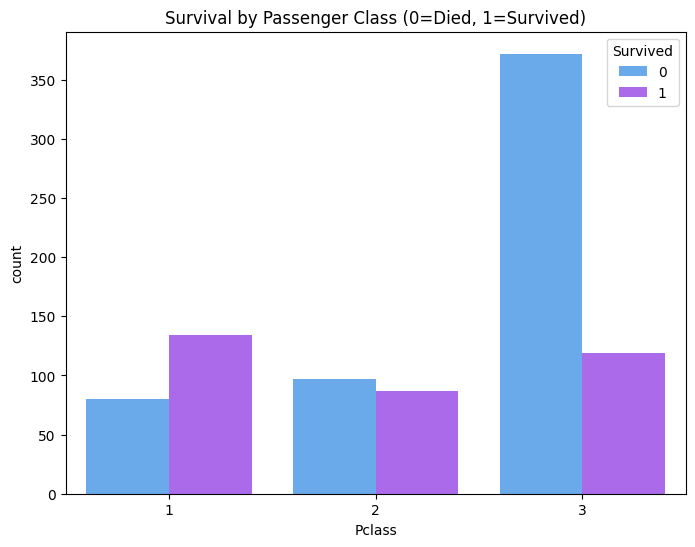

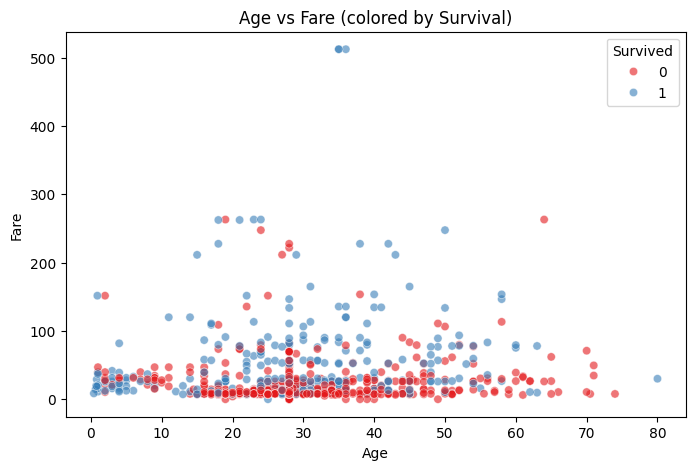

In [83]:
# Distribution Of Age:
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True, color='Navy')
plt.title('Distribution of Age')
plt.show()
plt.savefig('age_distribution.png', dpi=150)
#OBSERVATION: most passangers are between age 20-40

# Distribution of Fare
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Fare'], color='red')
plt.title('Distribution of Fare')
plt.show()
plt.savefig('fare_distribution.png', dpi=150)
#OBSERVATION: most people paid less fare as the box plot is concentrated near the right end but a few paid very high fares (outliers).

# Survival Count 
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data=df, hue='Survived', palette='Set2', legend=False)
plt.title('Survival Count (0=Died, 1=Survived)')
plt.savefig('survival_count.png', dpi=150)
plt.show()
#OBSERVATION: More people have died

# Survival by Gender
plt.figure(figsize=(8,6))
sns.countplot(x='Sex',hue='Survived', data=df, palette='Set1')
plt.title('Survival byh gender (0=Died, 1=Survived)')
plt.savefig('survival_by_gender.png', dpi=150)
plt.show()
#OBSERVATION: Females had a much higher survival rate than males.

# Survival by passenger class
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass',hue='Survived', data=df, palette='cool')
plt.title('Survival by Passenger Class (0=Died, 1=Survived)')
plt.savefig('survival_by_class.png', dpi=150)
plt.show()
#OBSERVATION: 3rd class passengers had the most death and 1st class survived the most

# Age vs Fare (On the basis of survival)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette='Set1', alpha=0.6)
plt.title('Age vs Fare (colored by Survival)')
plt.savefig('age_vs_fare.png', dpi=150)
plt.show()
#OBSERVATION: Fare was a stronger predictor of survival than age — passengers who paid higher fares survived more, while low-fare passengers mostly perished regardless of their age

____________________________________________________________________________________________________________________
### **Visualizing the data**
#### Plotting relationship using sns.pairplot(), sns.heatmap() :

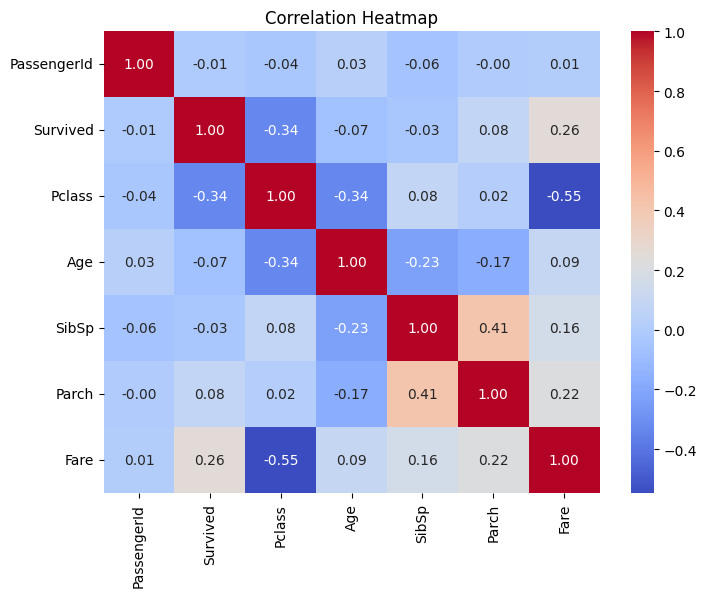

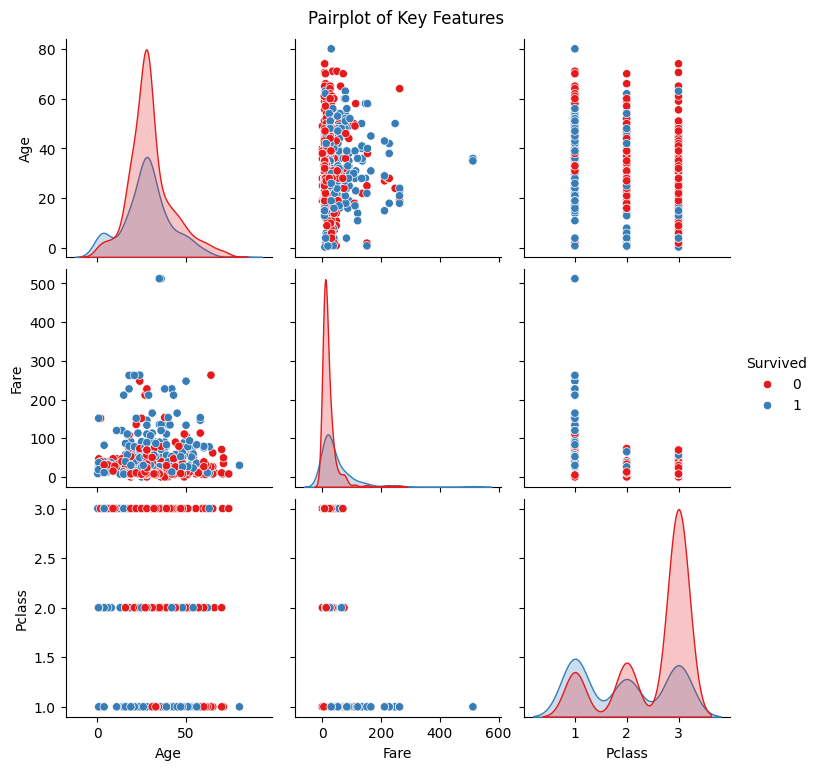

'\nOBSERVATION:\nMore the Fair lesser the chance of death\nHigher the class lesser the chance of death\nso, 1st class and high-fare passengers (blue) survived more, while 3rd class low-fare passengers (red) mostly died\n'

In [84]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png', dpi=150)
plt.show()
""" 
OBSERVATION:
1. Fare vs Survived have more correlation i.e. +0.26
Passengers who paid higher fares were more likely to survive.
2. Pclass vs Survived less correlation i.e. -0.34
Higher class number (3rd class) = lower survival. Negative because class 3 is a bigger number but worse outcome.
3. Pclass vs Fare least correlation i.e. -0.55 (darkest cell — strongest relationship)
1st class passengers paid much higher fares. Very logical.
4. SibSp vs Parch more correlation i.e. +0.41
People travelling with siblings/spouses also tended to travel with parents/children. They came as families.
5. Age vs Pclass less correlation i.e. -0.34
Older passengers tended to be in higher (better) classes.
6. PassengerId vs everything neary no correlation i.e. 0
PassengerId is just a serial number — no real relationship with anything
"""

# --- Pairplot (overview of all relationships) ---
sns.pairplot(df[['Age','Fare','Pclass','Survived']],hue='Survived',palette='Set1')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.savefig('pairplot.png', dpi=150)
plt.show()
"""
OBSERVATION:
More the Fair lesser the chance of death
Higher the class lesser the chance of death
so, 1st class and high-fare passengers (blue) survived more, while 3rd class low-fare passengers (red) mostly died
"""


____________________________________________________________________________________________________________________
### **Summary OF findings:**

1. **Gender**: Women had a Higher Survival rate than men
2. **Class**: People with ticket in higher class (1st class) survived the most 
3. **Fare**: People wo paid higher fair survived mostly
4. **Age**: Children had better survival. Middle-aged men had the worst
5. **Missing data**: Age 20% and Cabin 77% had significant missing values (Therefore cabin was dropped)
